In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# consistent style
sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams["figure.dpi"] = 130
plt.rcParams["figure.figsize"] = (12, 5)

In [6]:
df_full_forecast = pd.read_csv("la_forecast_data.csv")

# Conditions

In [8]:
# Cell — compute a simple outing score (0-100) for EDA purposes
# we'll refine this later but useful to visualize now

def compute_outing_score(row):
    score = 100

    # temperature penalty (ideal range 65-85°F)
    if row["temp_f"] < 50 or row["temp_f"] > 95:
        score -= 30
    elif row["temp_f"] < 60 or row["temp_f"] > 90:
        score -= 15

    # rain penalty
    if row["rain"] > 2:
        score -= 30
    elif row["rain"] > 0:
        score -= 15

    # AQI penalty (1=Good, 5=Very Poor)
    aqi_penalties = {1: 0, 2: 5, 3: 20, 4: 35, 5: 50}
    score -= aqi_penalties.get(row["aqi"], 0)

    # wind penalty
    if row["wind_mph"] > 25:
        score -= 15
    elif row["wind_mph"] > 15:
        score -= 5

    return max(0, min(100, score))

df_full_forecast["outing_score"] = df_full_forecast.apply(compute_outing_score, axis=1)
print("Outing score stats:")
print(df_full_forecast["outing_score"].describe())
df_full_forecast[["neighborhood", "timestamp", "temp_f", "aqi", "rain", "outing_score"]].head(10)

Outing score stats:
count    256.000000
mean      81.523438
std       14.349402
min       50.000000
25%       80.000000
50%       80.000000
75%       95.000000
max       95.000000
Name: outing_score, dtype: float64


,neighborhood,timestamp,temp_f,aqi,rain,outing_score
0,Downtown,2026-05-04 11:00:00,61.72,2,0.00,95
1,Downtown,2026-05-04 14:00:00,63.66,2,0.00,95
2,Downtown,2026-05-04 17:00:00,63.93,2,0.00,90
3,Downtown,2026-05-04 20:00:00,60.33,3,0.00,80
4,Downtown,2026-05-04 23:00:00,57.09,3,0.30,50
5,Downtown,2026-05-05 02:00:00,58.78,3,0.46,50
6,Downtown,2026-05-05 05:00:00,58.19,3,0.29,50
7,Downtown,2026-05-05 08:00:00,59.70,3,0.00,65
8,Downtown,2026-05-05 11:00:00,65.21,3,0.00,80
9,Downtown,2026-05-05 14:00:00,67.44,3,0.00,80


C:\Users\Chris\AppData\Local\Temp\ipykernel_12160\1066791931.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_full_forecast, x="neighborhood", y="outing_score", order=order, palette="coolwarm_r")


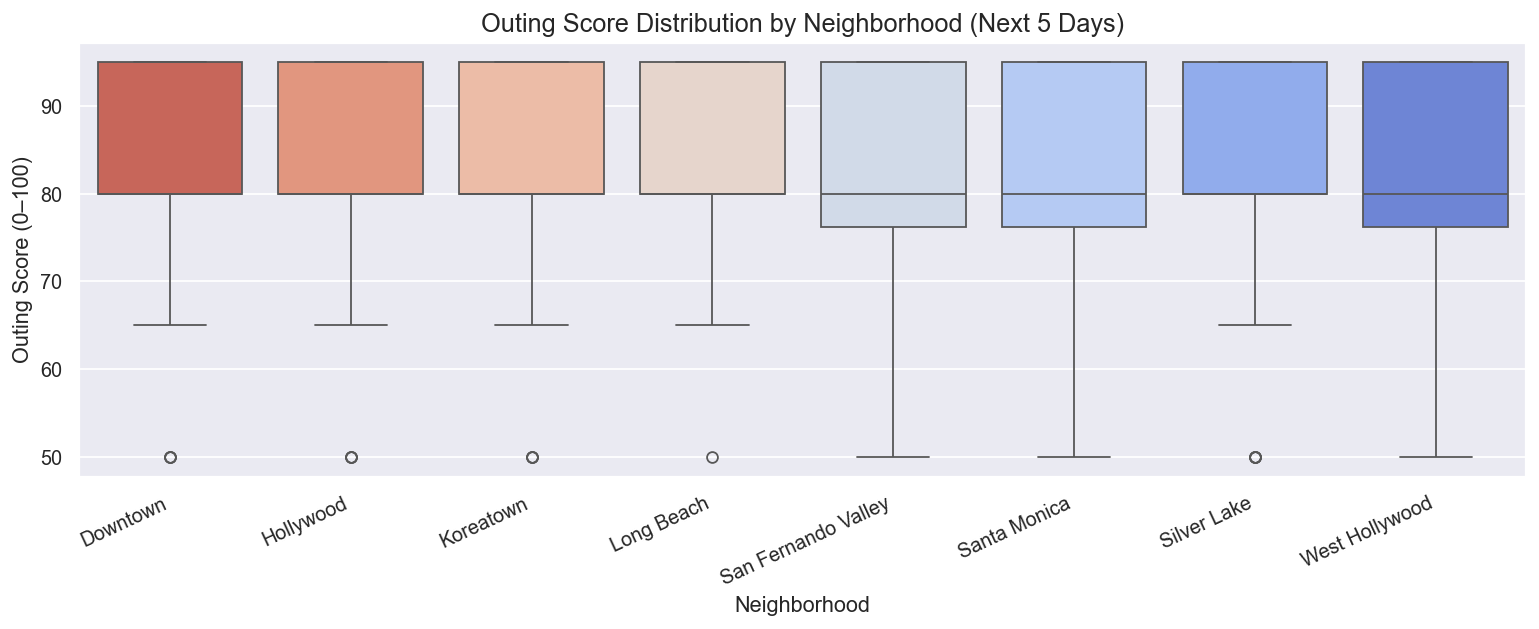

In [14]:
# Cell — 1: Outing Score Distribution by Neighborhood
plt.figure(figsize=(12, 5))
order = df_full_forecast.groupby("neighborhood")["outing_score"].median().sort_values(ascending=False).index
sns.boxplot(data=df_full_forecast, x="neighborhood", y="outing_score", order=order, palette="coolwarm_r")
plt.title("Outing Score Distribution by Neighborhood (Next 5 Days)", fontsize=14)
plt.xlabel("Neighborhood")
plt.ylabel("Outing Score (0–100)")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.savefig("outing_score_by_neighborhood.png", bbox_inches="tight")
plt.show()

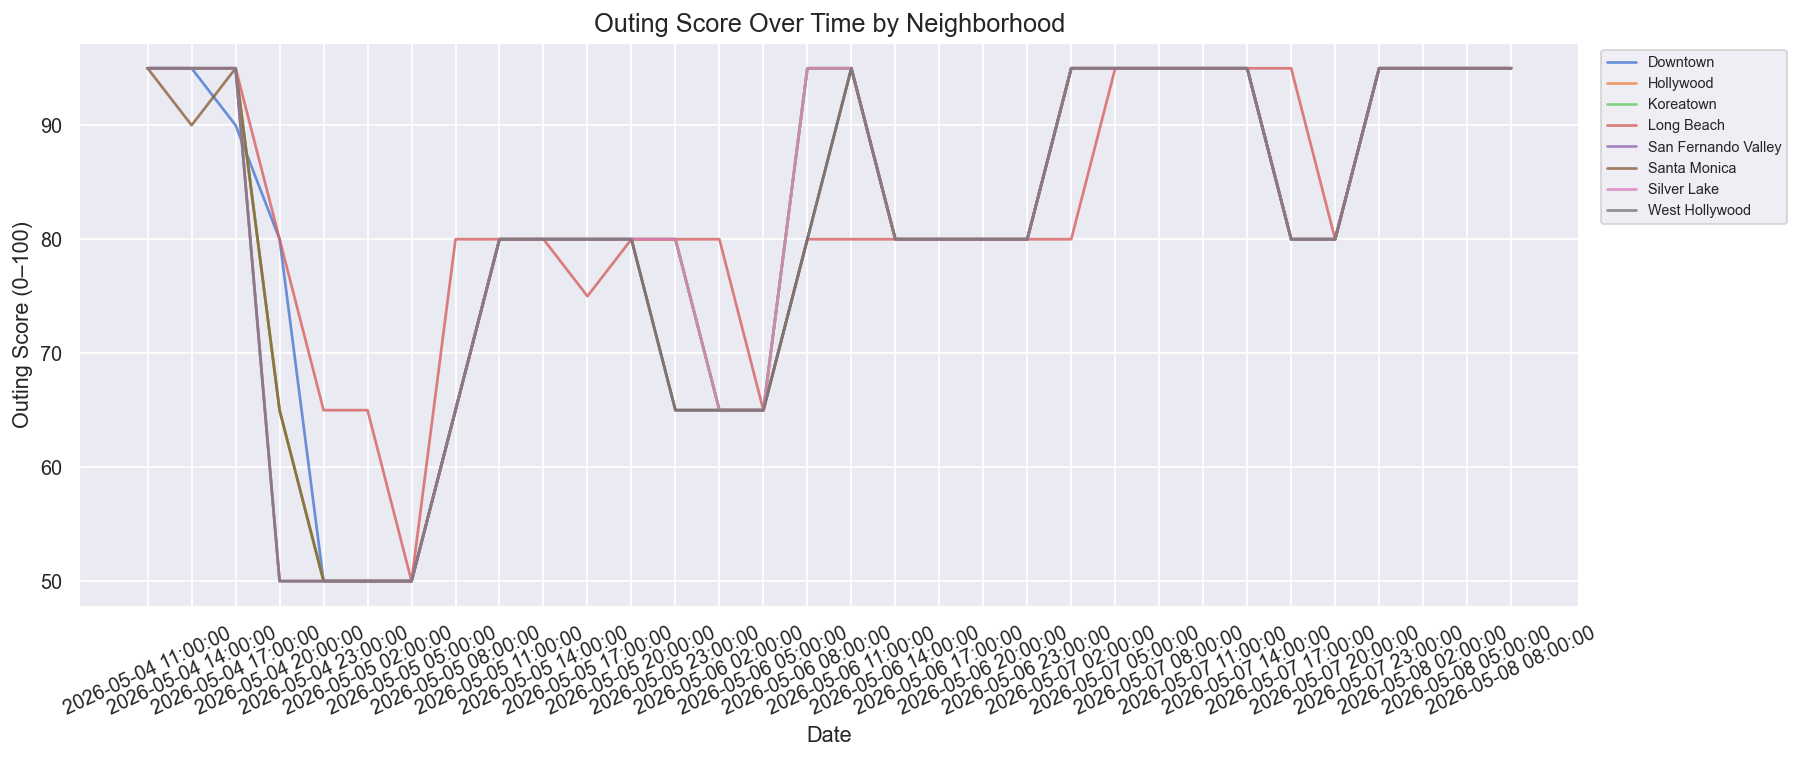

In [16]:
# Cell — 2: Outing Score Over Time (line chart per neighborhood)
plt.figure(figsize=(14, 6))
for neighborhood, group in df_full_forecast.groupby("neighborhood"):
    plt.plot(group["timestamp"], group["outing_score"], label=neighborhood, alpha=0.8)
plt.title("Outing Score Over Time by Neighborhood", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Outing Score (0–100)")
plt.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.xticks(rotation=25)
plt.tight_layout()
plt.savefig("outing_score_over_time.png", bbox_inches="tight")
plt.show()

C:\Users\Chris\AppData\Local\Temp\ipykernel_12160\4198437112.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_full_forecast, x="neighborhood", y="temp_f", order=order, palette="coolwarm")


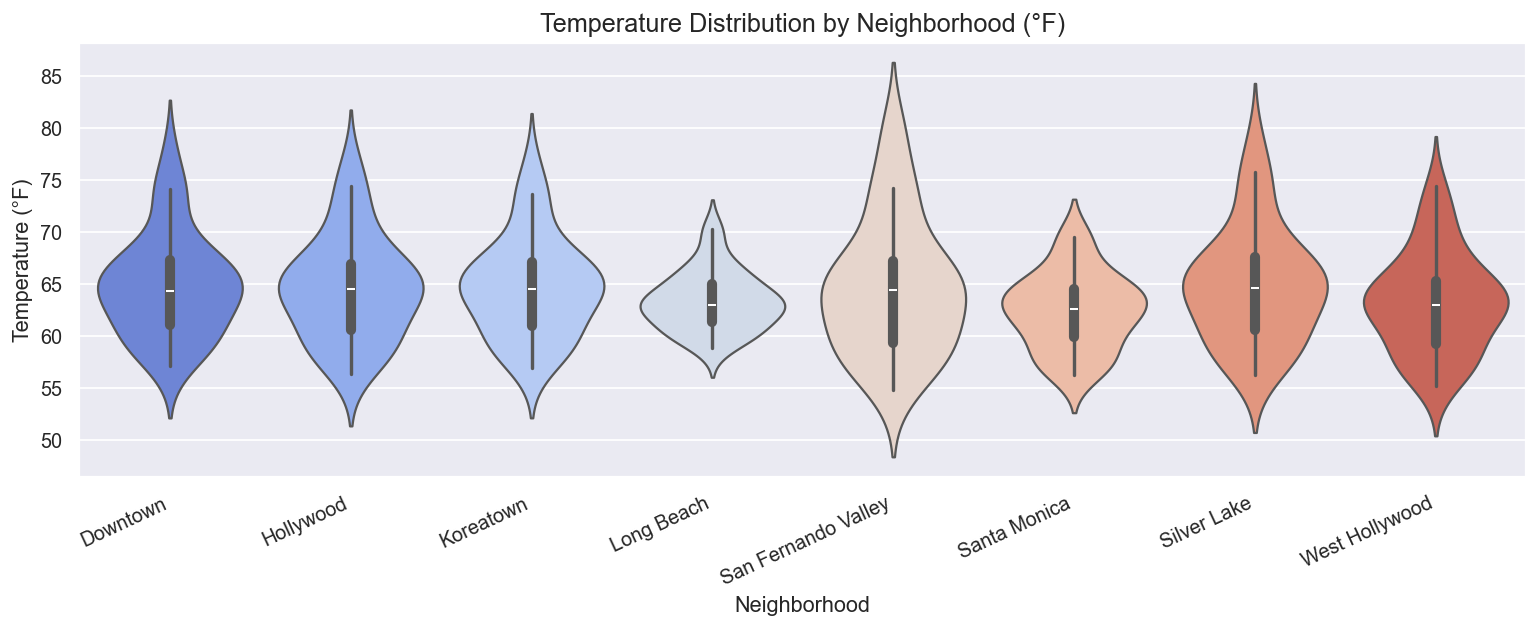

In [18]:
# Cell — 3: Temperature Distribution by Neighborhood
plt.figure(figsize=(12, 5))
sns.violinplot(data=df_full_forecast, x="neighborhood", y="temp_f", order=order, palette="coolwarm")
plt.title("Temperature Distribution by Neighborhood (°F)", fontsize=14)
plt.xlabel("Neighborhood")
plt.ylabel("Temperature (°F)")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.savefig("temp_distribution.png", bbox_inches="tight")
plt.show()

0      2026-05-04
1      2026-05-04
2      2026-05-04
3      2026-05-04
4      2026-05-04
          ...    
251    2026-05-07
252    2026-05-07
253    2026-05-08
254    2026-05-08
255    2026-05-08
Name: timestamp, Length: 256, dtype: object

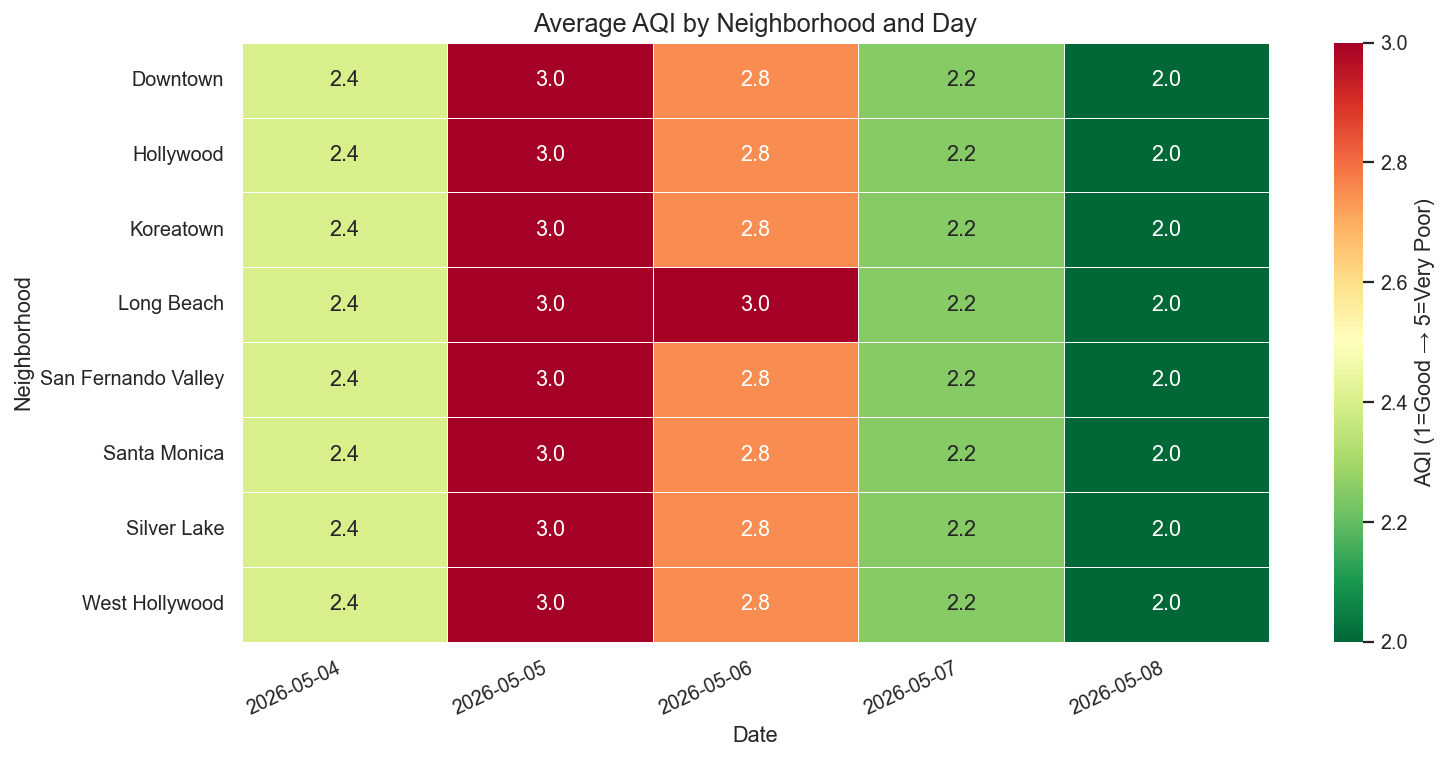

In [74]:
# Cell — 4: AQI Heatmap (neighborhood vs day)
df_full_forecast["date"] = pd.to_datetime(df_full_forecast["timestamp"]).dt.date
aqi_pivot = df_full_forecast.groupby(["neighborhood", "date"])["aqi"].mean().unstack()

plt.figure(figsize=(12, 6))
sns.heatmap(aqi_pivot, annot=True, fmt=".1f", cmap="RdYlGn_r", 
            linewidths=0.5, cbar_kws={"label": "AQI (1=Good → 5=Very Poor)"})
plt.title("Average AQI by Neighborhood and Day", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Neighborhood")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.savefig("aqi_heatmap.png", bbox_inches="tight")
plt.show()

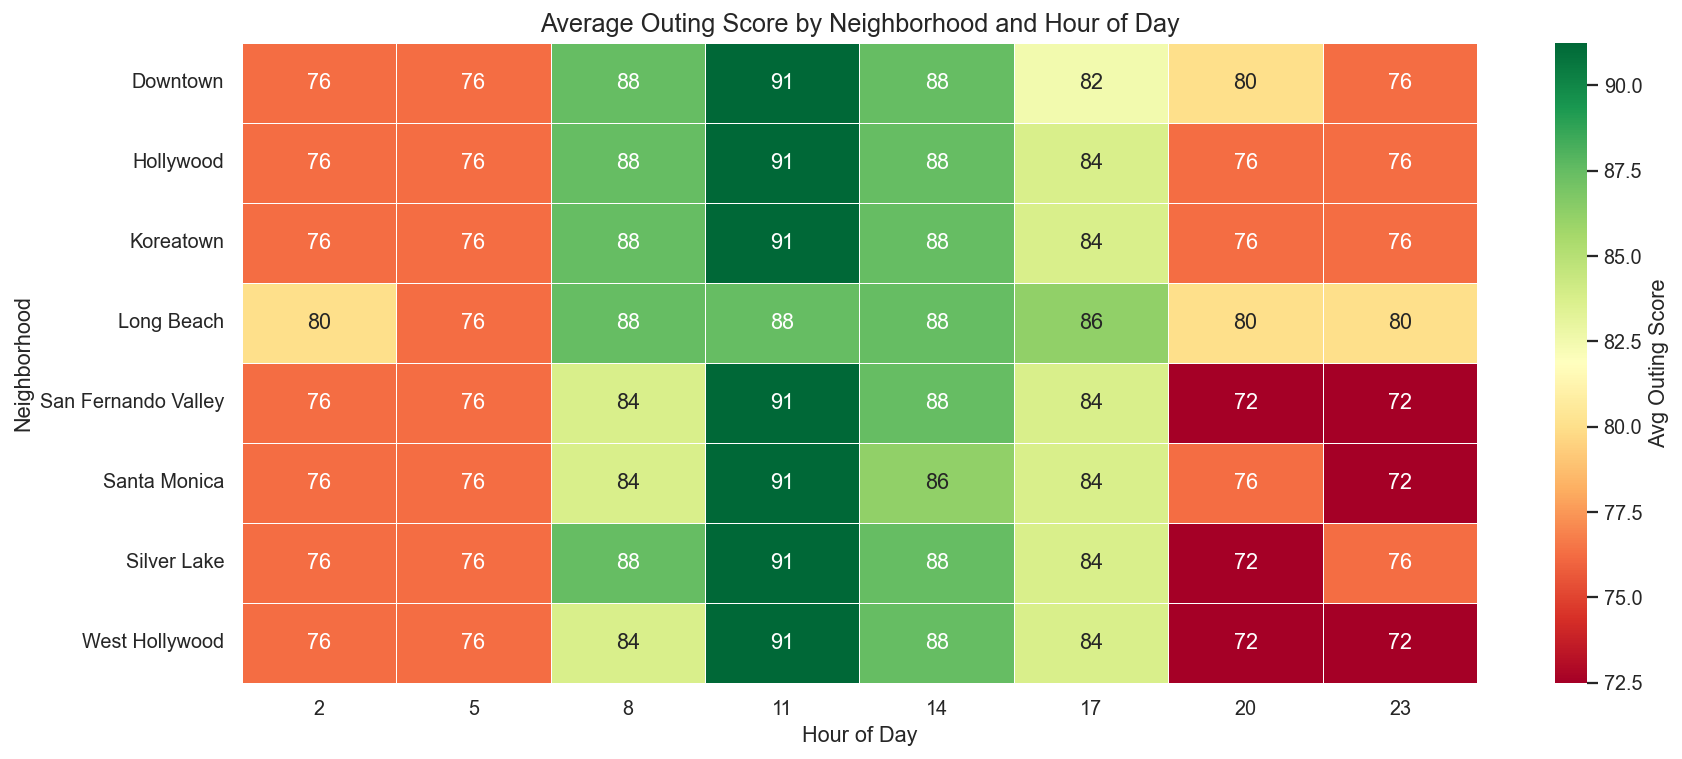

In [46]:
# Cell — 5: Outing Score Heatmap (neighborhood vs hour of day)
outing_pivot = df_full_forecast.groupby(["neighborhood", "hour"])["outing_score"].mean().unstack()

plt.figure(figsize=(14, 6))
sns.heatmap(outing_pivot, annot=True, fmt=".0f", cmap="RdYlGn",
            linewidths=0.5, cbar_kws={"label": "Avg Outing Score"})
plt.title("Average Outing Score by Neighborhood and Hour of Day", fontsize=14)
plt.xlabel("Hour of Day")
plt.ylabel("Neighborhood")
plt.tight_layout()
plt.savefig("outing_score_heatmap.png", bbox_inches="tight")
plt.show()

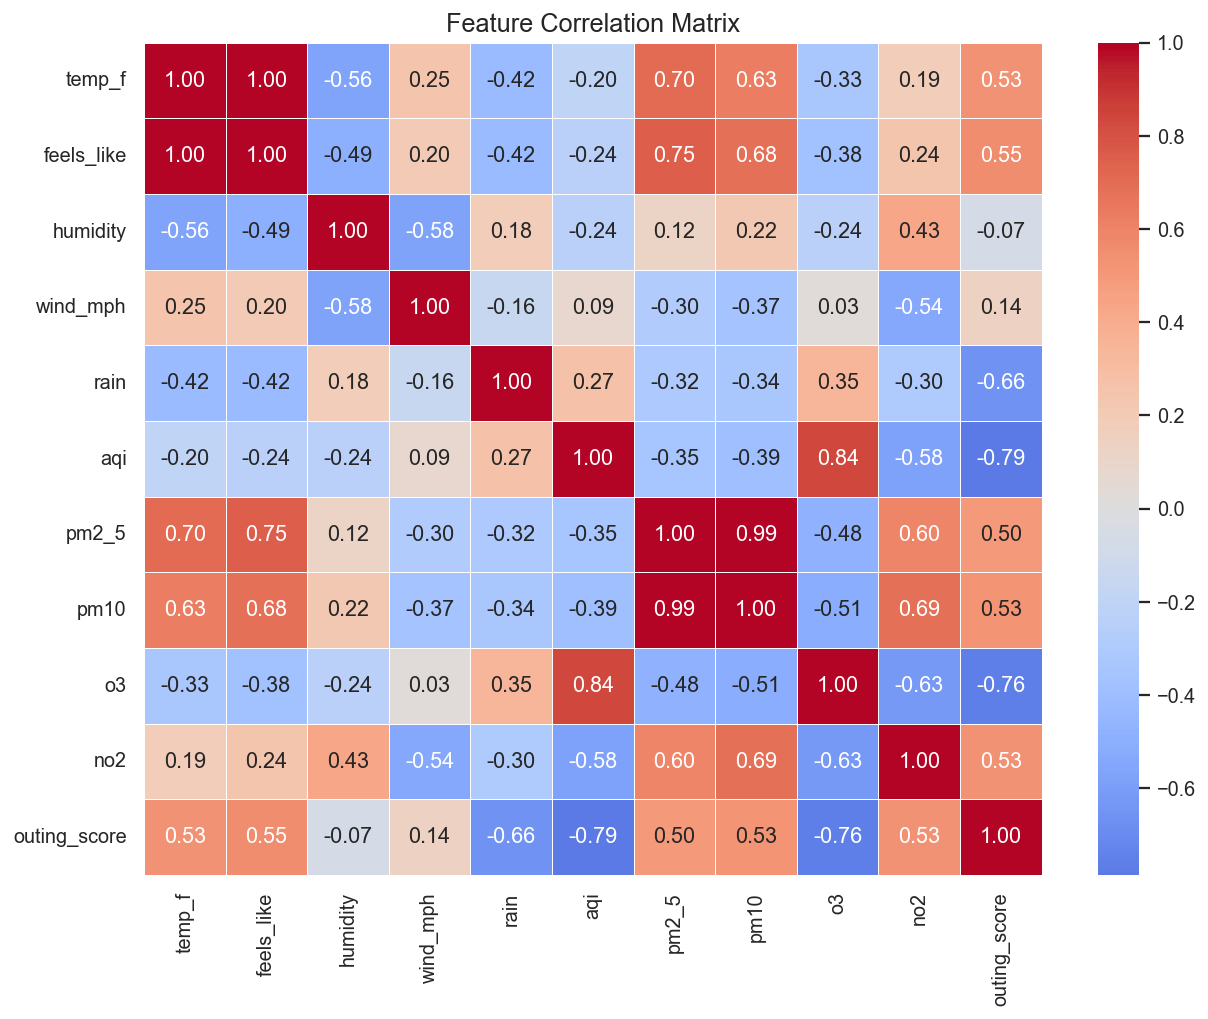

In [48]:
# Cell — 6: Correlation heatmap of all numeric features
numeric_cols = ["temp_f", "feels_like", "humidity", "wind_mph", "rain", "aqi", "pm2_5", "pm10", "o3", "no2", "outing_score"]
plt.figure(figsize=(10, 8))
sns.heatmap(df_full_forecast[numeric_cols].corr(), annot=True, fmt=".2f",
            cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Feature Correlation Matrix", fontsize=14)
plt.tight_layout()
plt.savefig("correlation_matrix.png", bbox_inches="tight")
plt.show()

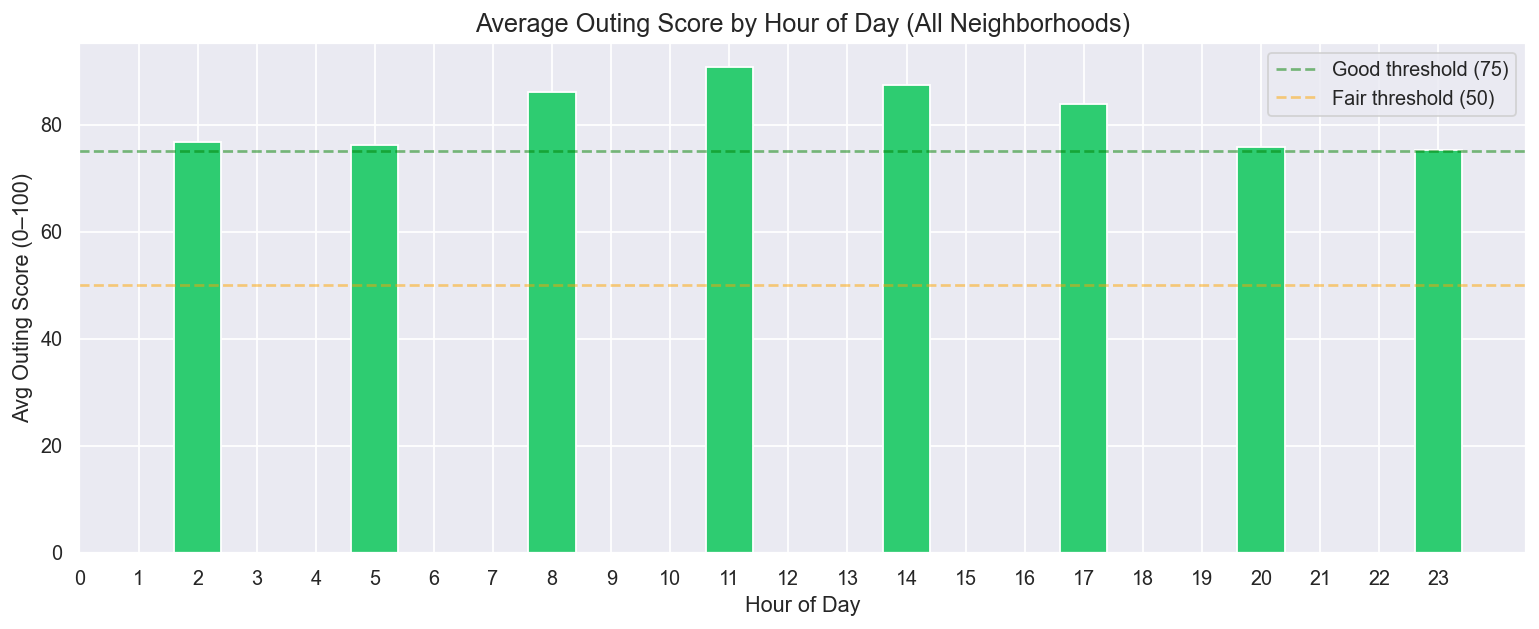

In [123]:
# Cell — 7: Best time to go out (avg outing score by hour)
hourly = df_full_forecast.groupby("hour")["outing_score"].mean().reset_index()
plt.figure(figsize=(12, 5))
bars = plt.bar(hourly["hour"], hourly["outing_score"], 
               color=["#2ecc71" if s >= 75 else "#f39c12" if s >= 50 else "#e74c3c" 
                      for s in hourly["outing_score"]])
plt.title("Average Outing Score by Hour of Day (All Neighborhoods)", fontsize=14)
plt.xlabel("Hour of Day")
plt.ylabel("Avg Outing Score (0–100)")
plt.xticks(range(0, 24))
plt.axhline(y=75, color="green", linestyle="--", alpha=0.5, label="Good threshold (75)")
plt.axhline(y=50, color="orange", linestyle="--", alpha=0.5, label="Fair threshold (50)")
plt.legend()
plt.tight_layout()
plt.savefig("best_hour_to_go_out.png", bbox_inches="tight")
plt.show()

# Restaurants

In [80]:
df_restaurants = pd.read_csv("google_restaurants_training.csv")

C:\Users\Chris\AppData\Local\Temp\ipykernel_12160\3934047826.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_restaurants, x="city", y="rating", ax=axes[1], palette="muted")
C:\Users\Chris\AppData\Local\Temp\ipykernel_12160\3934047826.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_restaurants, x="price_level", y="rating", ax=axes[2], palette="coolwarm")


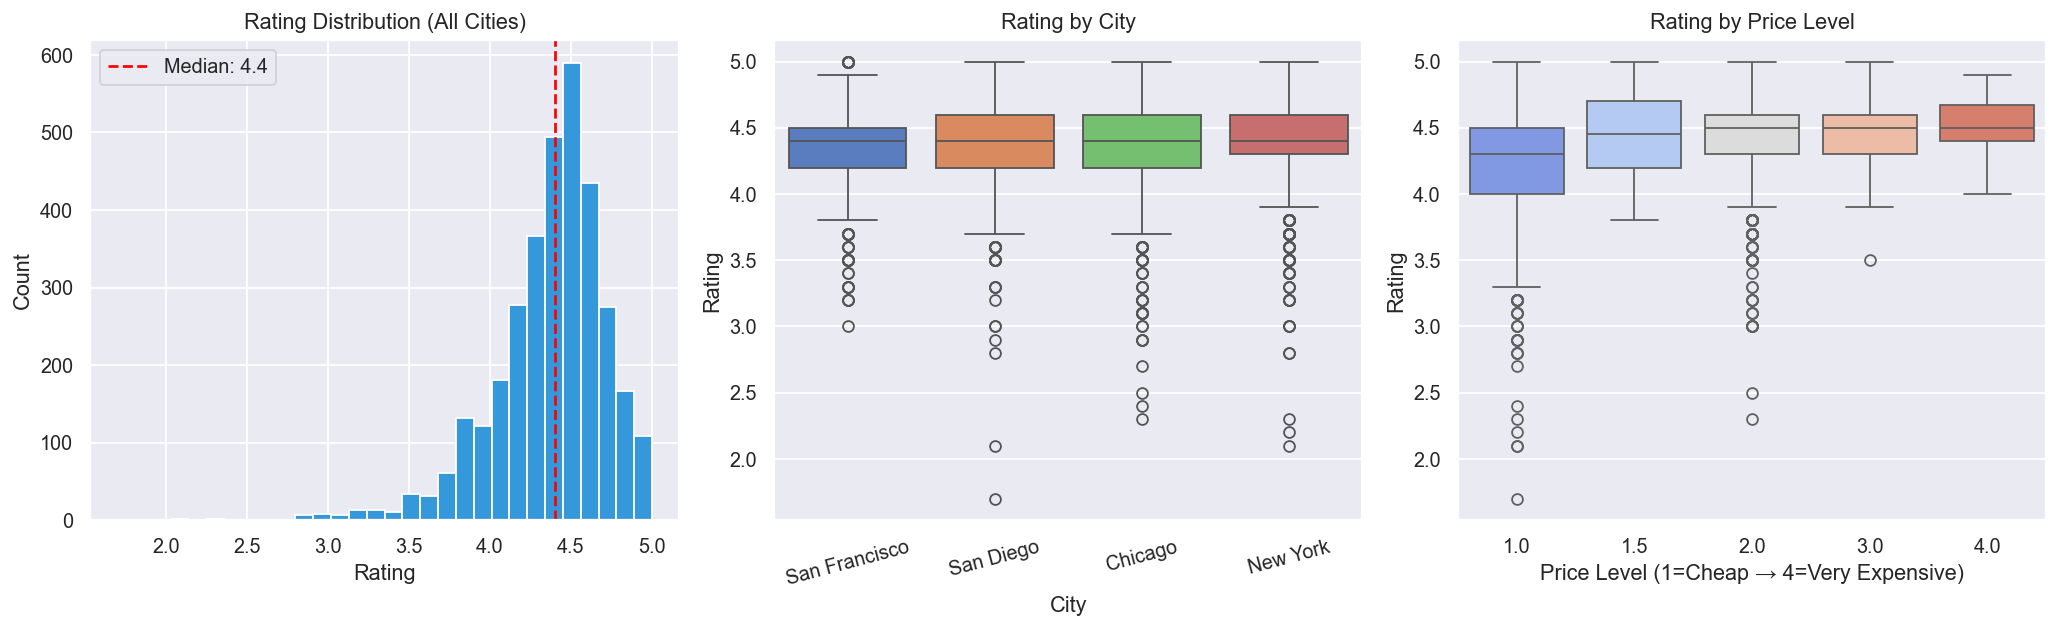

In [82]:
# Cell — rating distribution visualization
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. overall rating histogram
axes[0].hist(df_restaurants["rating"], bins=30, color="#3498db", edgecolor="white")
axes[0].axvline(df_restaurants["rating"].median(), color="red", 
                linestyle="--", label=f'Median: {df_restaurants["rating"].median()}')
axes[0].set_title("Rating Distribution (All Cities)")
axes[0].set_xlabel("Rating")
axes[0].set_ylabel("Count")
axes[0].legend()

# 2. rating by city
sns.boxplot(data=df_restaurants, x="city", y="rating", ax=axes[1], palette="muted")
axes[1].set_title("Rating by City")
axes[1].set_xlabel("City")
axes[1].set_ylabel("Rating")
axes[1].tick_params(axis='x', rotation=15)

# 3. rating by price level
sns.boxplot(data=df_restaurants, x="price_level", y="rating", ax=axes[2], palette="coolwarm")
axes[2].set_title("Rating by Price Level")
axes[2].set_xlabel("Price Level (1=Cheap → 4=Very Expensive)")
axes[2].set_ylabel("Rating")

plt.tight_layout()
plt.savefig("restaurant_rating_eda.png", bbox_inches="tight")
plt.show()

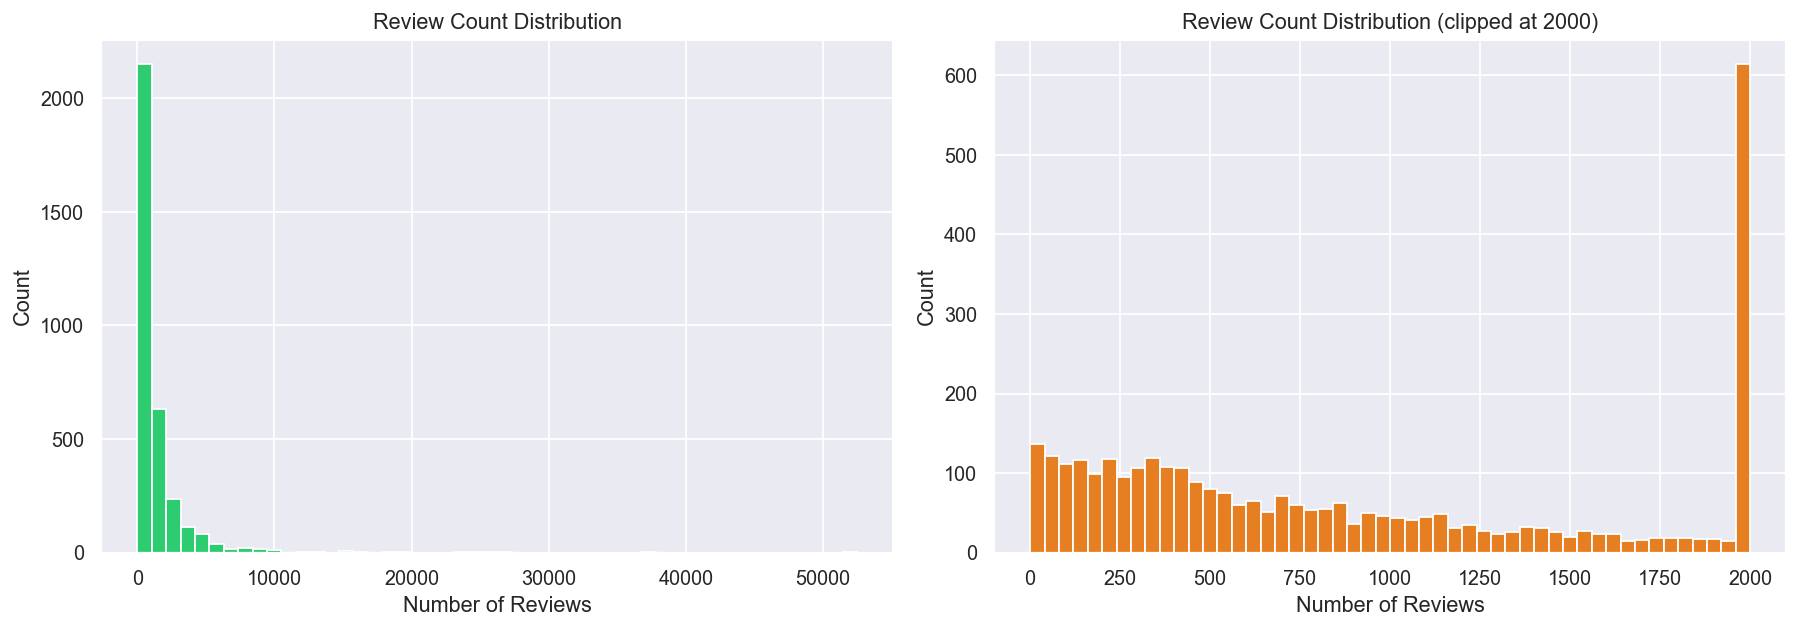

Review count stats:
count     3343.000000
mean      1353.521687
std       2360.736771
min          1.000000
25%        293.000000
50%        686.000000
75%       1490.000000
max      52505.000000
Name: user_rating_count, dtype: float64


In [84]:
# Cell — user rating count distribution (proxy for popularity)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# log scale because review counts are heavily skewed
axes[0].hist(df_restaurants["user_rating_count"], bins=50, color="#2ecc71", edgecolor="white")
axes[0].set_title("Review Count Distribution")
axes[0].set_xlabel("Number of Reviews")
axes[0].set_ylabel("Count")

axes[1].hist(df_restaurants["user_rating_count"].clip(upper=2000), 
             bins=50, color="#e67e22", edgecolor="white")
axes[1].set_title("Review Count Distribution (clipped at 2000)")
axes[1].set_xlabel("Number of Reviews")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.savefig("review_count_distribution.png", bbox_inches="tight")
plt.show()

print("Review count stats:")
print(df_restaurants["user_rating_count"].describe())

In [119]:
df_restaurants.cuisine.value_counts()

cuisine
Mexican Restaurant      394
Chinese Restaurant      280
Italian Restaurant      267
Restaurant              243
Thai Restaurant         178
                       ... 
Cambodian Restaurant      1
German Restaurant         1
British Restaurant        1
Cafeteria                 1
Colombian Restaurant      1
Name: count, Length: 141, dtype: int64

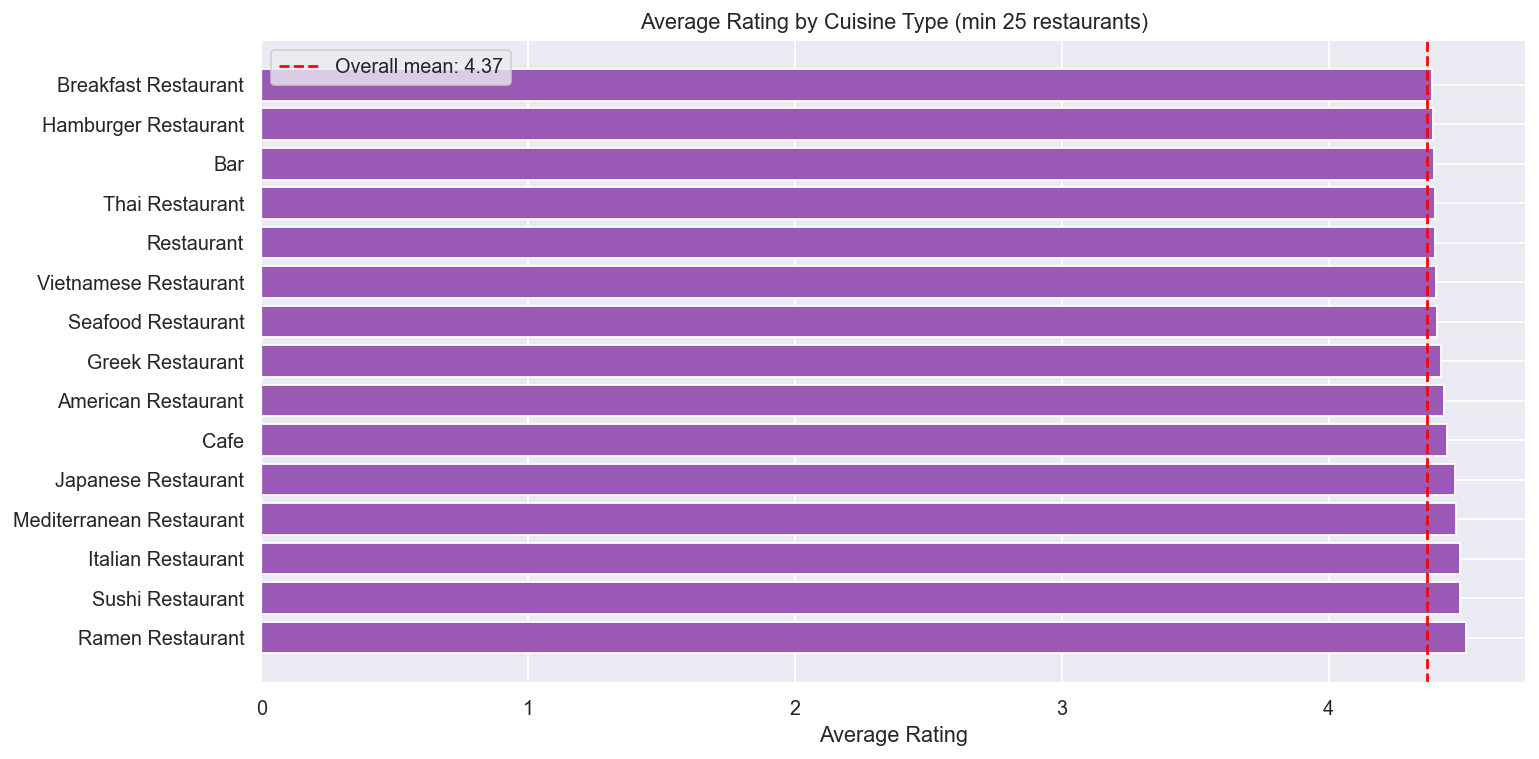

In [121]:
# Cell — top cuisines by average rating
cuisine_stats = df_restaurants.groupby("cuisine").agg(
    avg_rating=("rating", "mean"),
    count=("rating", "count")
).query("count >= 25").sort_values("avg_rating", ascending=False).head(15)

plt.figure(figsize=(12, 6))
bars = plt.barh(cuisine_stats.index, cuisine_stats["avg_rating"], color="#9b59b6")
plt.axvline(df_restaurants["rating"].mean(), color="red", 
            linestyle="--", label=f'Overall mean: {df_restaurants["rating"].mean():.2f}')
plt.title("Average Rating by Cuisine Type (min 25 restaurants)")
plt.xlabel("Average Rating")
plt.legend()
plt.tight_layout()
plt.savefig("rating_by_cuisine.png", bbox_inches="tight")
plt.show()

In [92]:
# Cell — percentile-based tiered labels
import numpy as np

# calculate percentile thresholds from the actual data
p35 = df_restaurants["rating"].quantile(0.35)
p65 = df_restaurants["rating"].quantile(0.65)
p90 = df_restaurants["rating"].quantile(0.90)

print("Percentile thresholds:")
print(f"  35th percentile: {p35}")
print(f"  65th percentile: {p65}")
print(f"  90th percentile: {p90}")

# define 4 tiers
def label_4tier(rating):
    if rating >= p90:
        return 3  # 🌟 Hidden gem / Must go
    elif rating >= p65:
        return 2  # 🟢 Worth the trip
    elif rating >= p35:
        return 1  # 🟡 Decent
    else:
        return 0  # 🔴 Skip it

df_restaurants["label"] = df_restaurants["rating"].apply(label_4tier)

label_names = {
    0: f"Skip it\n(<{p35:.2f})",
    1: f"Decent\n({p35:.2f}–{p65:.2f})",
    2: f"Worth the trip\n({p65:.2f}–{p90:.2f})",
    3: f"Must go\n(≥{p90:.2f})"
}

counts = df_restaurants["label"].value_counts().sort_index()
print("\nClass distribution:")
for label, count in counts.items():
    pct = count / len(df_restaurants) * 100
    print(f"  {label_names[label].replace(chr(10), ' ')}: {count} ({pct:.1f}%)")

Percentile thresholds:
  35th percentile: 4.3
  65th percentile: 4.5
  90th percentile: 4.7

Class distribution:
  Skip it (<4.30): 906 (27.1%)
  Decent (4.30–4.50): 861 (25.8%)
  Worth the trip (4.50–4.70): 1025 (30.7%)
  Must go (≥4.70): 551 (16.5%)


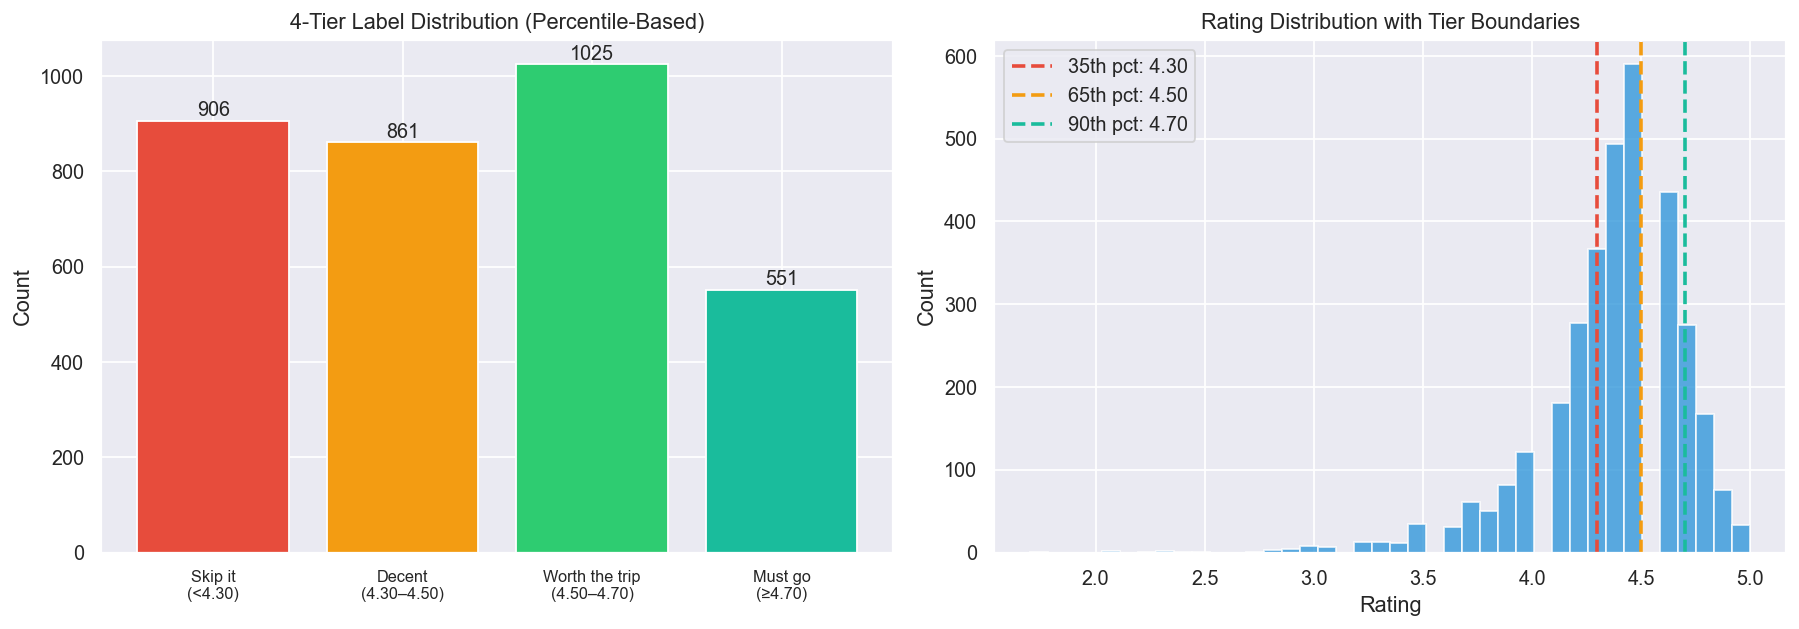

In [94]:
# Cell — visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# bar chart of class counts
colors = ["#e74c3c", "#f39c12", "#2ecc71", "#1abc9c"]
bars = axes[0].bar(
    [label_names[i] for i in range(4)],
    [counts[i] for i in range(4)],
    color=colors
)
for bar, count in zip(bars, [counts[i] for i in range(4)]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 str(count), ha="center", fontsize=11)
axes[0].set_title("4-Tier Label Distribution (Percentile-Based)")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', labelsize=9)

# rating histogram with tier boundaries overlaid
axes[1].hist(df_restaurants["rating"], bins=40, color="#3498db", 
             edgecolor="white", alpha=0.8)
axes[1].axvline(p35, color="#e74c3c", linestyle="--", linewidth=2, label=f"35th pct: {p35:.2f}")
axes[1].axvline(p65, color="#f39c12", linestyle="--", linewidth=2, label=f"65th pct: {p65:.2f}")
axes[1].axvline(p90, color="#1abc9c", linestyle="--", linewidth=2, label=f"90th pct: {p90:.2f}")
axes[1].set_title("Rating Distribution with Tier Boundaries")
axes[1].set_xlabel("Rating")
axes[1].set_ylabel("Count")
axes[1].legend()

plt.tight_layout()
plt.savefig("4tier_label_distribution.png", bbox_inches="tight")
plt.show()

In [97]:
# Cell — save with 4-tier labels
df_restaurants.to_csv("google_restaurants_training_clean.csv", index=False)
print(f"Saved {len(df_restaurants)} restaurants with 4-tier labels")
print(f"\nThresholds stored:")
print(f"  p35 = {p35}, p65 = {p65}, p90 = {p90}")
print("\nIMPORTANT: Save these thresholds — needed to label LA restaurants at inference time")

Saved 3343 restaurants with 4-tier labels

Thresholds stored:
  p35 = 4.3, p65 = 4.5, p90 = 4.7

IMPORTANT: Save these thresholds — needed to label LA restaurants at inference time


In [99]:
# Cell — save thresholds as part of the pipeline
import json

thresholds = {
    "p35": p35,
    "p65": p65,
    "p90": p90,
    "labels": {
        0: "Skip it",
        1: "Decent",
        2: "Worth the trip",
        3: "Must go"
    },
    "boundaries": {
        "skip_it": f"< {p35}",
        "decent": f"{p35} – {p65}",
        "worth_the_trip": f"{p65} – {p90}",
        "must_go": f">= {p90}"
    }
}

with open("label_thresholds.json", "w") as f:
    json.dump(thresholds, f, indent=2)

print("Thresholds saved to label_thresholds.json")
print(json.dumps(thresholds, indent=2))

Thresholds saved to label_thresholds.json
{
  "p35": 4.3,
  "p65": 4.5,
  "p90": 4.7,
  "labels": {
    "0": "Skip it",
    "1": "Decent",
    "2": "Worth the trip",
    "3": "Must go"
  },
  "boundaries": {
    "skip_it": "< 4.3",
    "decent": "4.3 \u2013 4.5",
    "worth_the_trip": "4.5 \u2013 4.7",
    "must_go": ">= 4.7"
  }
}
